<a href="https://colab.research.google.com/github/mnguyen175/DRSP-2026-Maryan-Nguyen-/blob/main/DRSP_Final_Project_2026_Maryan_Nguyen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd # import pandas
import numpy as np

!pip install matplotlib # import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("/content/nyt_bestsellers_combined.csv")
df['week'] = pd.to_datetime(df['week'])
df['first_week'] = pd.to_datetime(df['first_week'])

In [2]:
df = pd.read_csv("/content/nyt_bestsellers_combined.csv")
df.head(5)

,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.shape # 60386 rows (instances), 11 columns (variables)

In [ ]:
df.info() # author has null objects, there are only objects and ints in the dataset

In [ ]:
df.describe()

In [ ]:
df.columns

In [ ]:
print(df['week'].head())
print(df['first_week'].head())

In [ ]:
df.isna().sum() # confirm that author has 10 null values

In [ ]:
df.duplicated().sum()

In [8]:
df[df['author'].isna()][['title_id', 'title', 'week']].drop_duplicates()

df['author'] = df['author'].fillna("Unknown")

In [9]:
df.duplicated(subset=['week', 'title_id',]).sum()

np.int64(0)

In [10]:
# Sort chronologically first
df = df.sort_values(["year", "week", "rank"]).reset_index(drop=True)

# Number of previous bestseller appearances by the author
df["prior_author_appearances"] = df.groupby("author").cumcount()

df["prior_author_appearances"].value_counts().sort_index()
df[["author", "prior_author_appearances"]].value_counts().sort_index()

author                                            prior_author_appearances
  Martha Grimes                                   0                           1
 Elizabeth Forsythe Hailey                        0                           1
 James A. Michener                                0                           1
 Maxence van der Meersch                          0                           1
                                                  1                           1
                                                                             ..
written and illustrated by Mattie J. T. Stepanek  25                          1
                                                  26                          1
                                                  27                          1
                                                  28                          1
written and illustrated by Mattie J.T. Stepanek   0                           1
Name: count, Length: 60386, dtype: int64

In [12]:
books_df = (
    df.sort_values(['title_id', 'week'])
    .groupby('title_id', as_index=False)
    .agg(
        title=('title', 'first'),
        author=('author', 'first'),
        pub_year=('pub_year','first'),
        first_week=('first_week','first'),
        debut_rank=('debut_rank','first'),
        best_rank=('best_rank','first'),
        total_weeks=('total_weeks','first'),
        observed_weeks=('week','nunique')
    )
)

print(df.shape)
print(books_df.shape)
books_df.head()

(60386, 12)
(7431, 9)


,title_id,title,author,pub_year,first_week,debut_rank,best_rank,total_weeks,observed_weeks
0,0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,1991-05-05,1,2,15,15
1,1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,1992-04-26,14,2,11,11
2,2,"""J"" IS FOR JUDGMENT",Sue Grafton,1993,1993-04-18,6,3,10,10
3,3,"""K"" IS FOR KILLER",Sue Grafton,1994,1994-04-24,12,2,9,9
4,4,"""L"" IS FOR LAWLESS",Sue Grafton,1995,1995-09-17,10,1,7,7


Text(0.5, 0, 'Times Appeared')

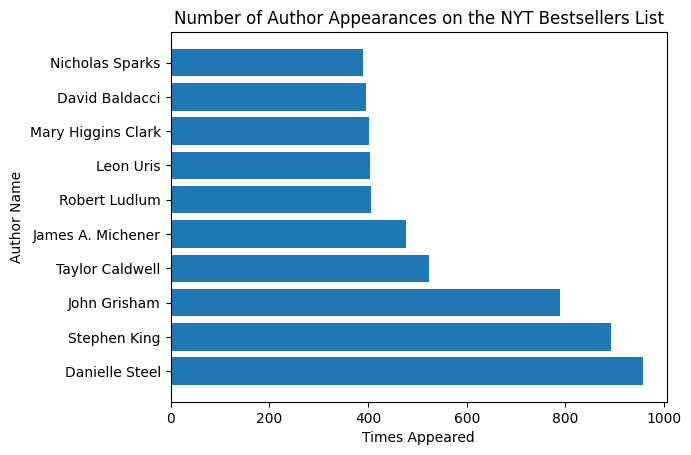

In [11]:
author_counts = df['author'].value_counts().head(10)

# plot the top 10 authors who have the most apperances on the nyt bestsellers list
plt.barh(author_counts.index, author_counts.values)
plt.title("Number of Author Appearances on the NYT Bestsellers List")
plt.ylabel("Author Name")
plt.xlabel("Times Appeared")

In [ ]:
book_appearances = df['title'].value_counts().head(10)

plt.barh(book_appearances.index, book_appearances.values)
plt.title("Most Book Appearances")
plt.xlabel("Number of Weeks")
plt.ylabel("Title")
plt.show()

In [ ]:
plt.scatter(df['debut_rank'], df['total_weeks'])

plt.title("Debut Rank vs. Total Weeks on NYT Bestsellers List")
plt.xlabel("Debut Rank")
plt.ylabel("Total Weeks")
plt.show()

In [ ]:
plt.hist(df['total_weeks'], bins=20)

plt.title('Distribution of Total Weeks on NYT Bestsellers List')
plt.xlabel('Number of Weeks')
plt.ylabel('Number of Books')
plt.show()

In [ ]:
books_per_pubyear = df['pub_year'].value_counts().sort_index()

plt.plot(books_per_pubyear.index, books_per_pubyear.values, color='teal')
plt.title("Number of Bestsellers From a Single Publishing Year")
plt.xlabel("Year")
plt.ylabel("Number of Books")
plt.show()

In [ ]:
books_per_year = df['year'].value_counts().sort_index()

plt.plot(books_per_year.index, books_per_year.values, color='purple')
plt.title("Number of Bestsellers Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Books")

In [13]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    books_df['debut_rank'],
    books_df['total_weeks']
)

print('Spearman correlation:', rho)
print('P-value:', p_value)

Spearman correlation: -0.012068023170564367
P-value: 0.2982629412139539


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = books_df[['debut_rank', 'pub_year']]
y = books_df['total_weeks']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

models = {
    'Baseline mean': DummyRegressor(strategy='mean'),
    'Linear regression': LinearRegression(),
    'Random forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=15,
        random_state=42
    )
}

results = []
for name, model in models.items():
  model.fit(X_train, y_train)
  predictions = model.predict(X_test)
  predictions = np.maximum(predictions, 0)

  results.append({
      'model':name,
      'MAE':mean_absolute_error(y_test,predictions),
      'RMSE':mean_squared_error(y_test,predictions)**0.5,
      'R2':r2_score(y_test,predictions)
    })

results_df = pd.DataFrame(results).sort_values('MAE')
results_df

,model,MAE,RMSE,R2
2,Random forest,5.866184,10.410817,0.164874
1,Linear regression,6.442406,10.867776,0.089953
0,Baseline mean,7.114884,11.392252,-0.000004
